# Final Competency Dataset Analysis

This notebook analyses the consolidated competency dataset and produces report-ready visualisations for the dissertation.

Focus areas:
- overall competency score distribution
- which skills score highest on average
- biography versus job-history contribution
- confidence score patterns
- top-ranked skill patterns across employees

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = Path("../data/outputs/final_competency_dataset.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,talentlinkId,skill_id,skill,category,declared_skills_json,is_declared_skill,position_text,job_history_text,biography_text,combined_text,biography_tfidf_score,job_description_tfidf_score,biography_confidence_score,job_description_confidence_score,confidence_score,sum_tfidf_score,biography_competency_score,job_description_competency_score,sum_competency_score,competency_score_rank
0,1043037,SK001,Data Analysis,Analytics,"[""Programme Delivery"", ""Risk Controls"", ""Regul...",True,Project Analyst Data Analyst Risk Analyst Cons...,Supported reporting and control improvements a...,Consulting professional supporting data qualit...,Consulting professional supporting data qualit...,0.038246,0.016935,0.4,0.0,20.0,0.055181,1.53,0.00,1.53,4
1,1043037,SK002,Data Governance,Governance,"[""Programme Delivery"", ""Risk Controls"", ""Regul...",True,Project Analyst Data Analyst Risk Analyst Cons...,Supported reporting and control improvements a...,Consulting professional supporting data qualit...,Consulting professional supporting data qualit...,0.087212,0.008641,0.7,0.4,55.0,0.095853,6.10,0.35,6.45,1
2,1043037,SK003,ETL Design,Data Engineering,"[""Programme Delivery"", ""Risk Controls"", ""Regul...",True,Project Analyst Data Analyst Risk Analyst Cons...,Supported reporting and control improvements a...,Consulting professional supporting data qualit...,Consulting professional supporting data qualit...,0.006935,0.000000,0.4,0.0,20.0,0.006935,0.28,0.00,0.28,9
3,1043037,SK004,Power BI,Analytics,"[""Programme Delivery"", ""Risk Controls"", ""Regul...",True,Project Analyst Data Analyst Risk Analyst Cons...,Supported reporting and control improvements a...,Consulting professional supporting data qualit...,Consulting professional supporting data qualit...,0.000000,0.000000,0.4,0.0,20.0,0.000000,0.00,0.00,0.00,-1
4,1043037,SK005,Programme Delivery,Delivery,"[""Programme Delivery"", ""Risk Controls"", ""Regul...",True,Project Analyst Data Analyst Risk Analyst Cons...,Supported reporting and control improvements a...,Consulting professional supporting data qualit...,Consulting professional supporting data qualit...,0.032555,0.093713,0.4,0.4,40.0,0.126268,1.30,3.75,5.05,2


In [4]:
summary = {
    "rows": len(df),
    "employees": df["talentlinkId"].nunique(),
    "skills": df["skill"].nunique(),
    "mean_sum_competency": round(df["sum_competency_score"].mean(), 3),
    "median_sum_competency": round(df["sum_competency_score"].median(), 3),
    "mean_biography_score": round(df["biography_competency_score"].mean(), 3),
    "mean_job_history_score": round(df["job_description_competency_score"].mean(), 3),
}
pd.Series(summary, name="value")

rows                      1050.000
employees                  105.000
skills                      10.000
mean_sum_competency          1.361
median_sum_competency        0.830
mean_biography_score         0.566
mean_job_history_score       0.795
Name: value, dtype: float64

## 1. Distribution of Final Competency Scores

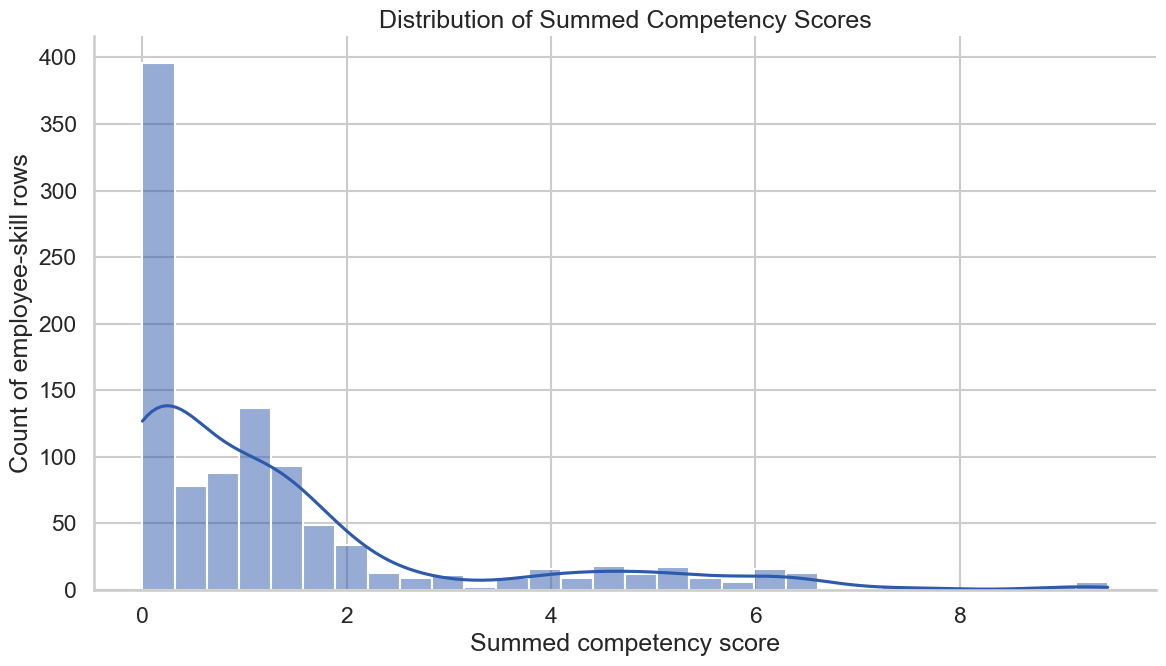

In [5]:
fig, ax = plt.subplots()
sns.histplot(df["sum_competency_score"], bins=30, kde=True, color="#2E5AAC", ax=ax)
ax.set_title("Distribution of Summed Competency Scores")
ax.set_xlabel("Summed competency score")
ax.set_ylabel("Count of employee-skill rows")
plt.tight_layout()
plt.show()

## 2. Average Competency Score by Skill

/var/folders/8d/dffstnrn5js2s44pz0sfhd1w0000gn/T/ipykernel_11234/3868818175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_means, y="skill", x="sum_competency_score", palette="Blues_r", ax=ax)


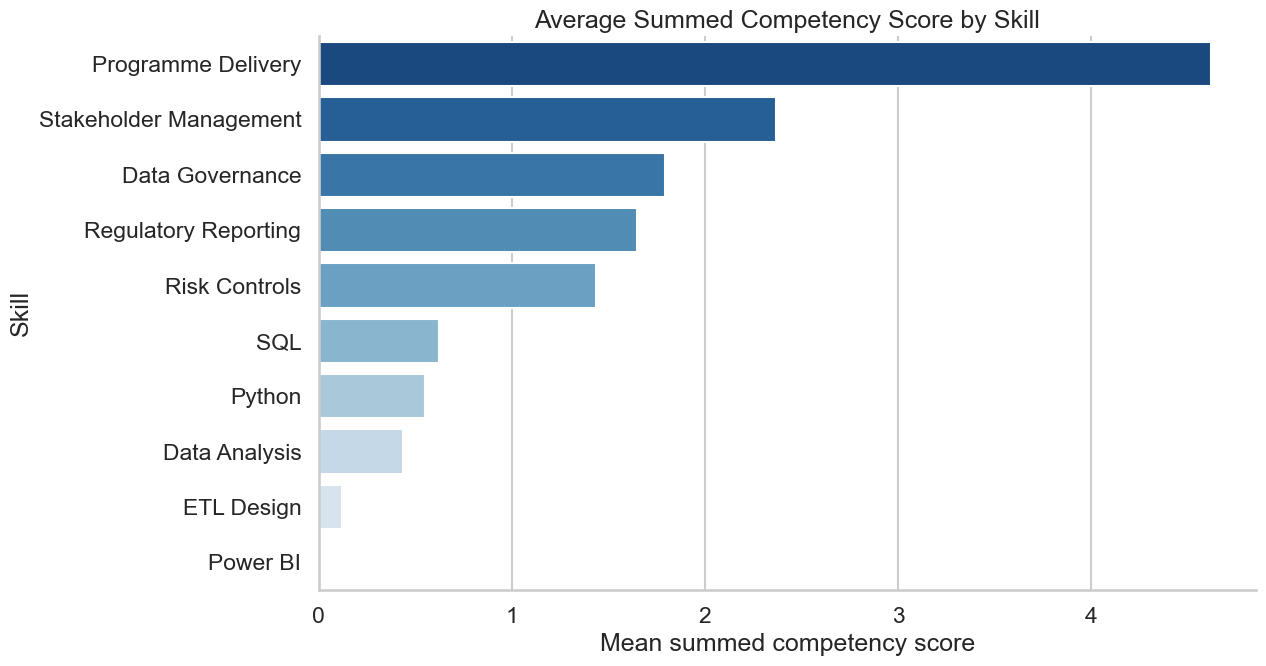

,skill,sum_competency_score
4,Programme Delivery,4.623429
9,Stakeholder Management,2.366952
1,Data Governance,1.793429
6,Regulatory Reporting,1.650190
7,Risk Controls,1.438190
8,SQL,0.625238
5,Python,0.548381
0,Data Analysis,0.437429
2,ETL Design,0.122095
3,Power BI,0.000000


In [6]:
skill_means = (
    df.groupby("skill", as_index=False)["sum_competency_score"]
    .mean()
    .sort_values("sum_competency_score", ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=skill_means, y="skill", x="sum_competency_score", palette="Blues_r", ax=ax)
ax.set_title("Average Summed Competency Score by Skill")
ax.set_xlabel("Mean summed competency score")
ax.set_ylabel("Skill")
plt.tight_layout()
plt.show()

skill_means

## 3. Biography Versus Job-History Contribution

/var/folders/8d/dffstnrn5js2s44pz0sfhd1w0000gn/T/ipykernel_11234/375354637.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_means, x="Source", y="Mean Competency Score", palette=["#5B8FF9", "#61DDAA"], ax=ax)


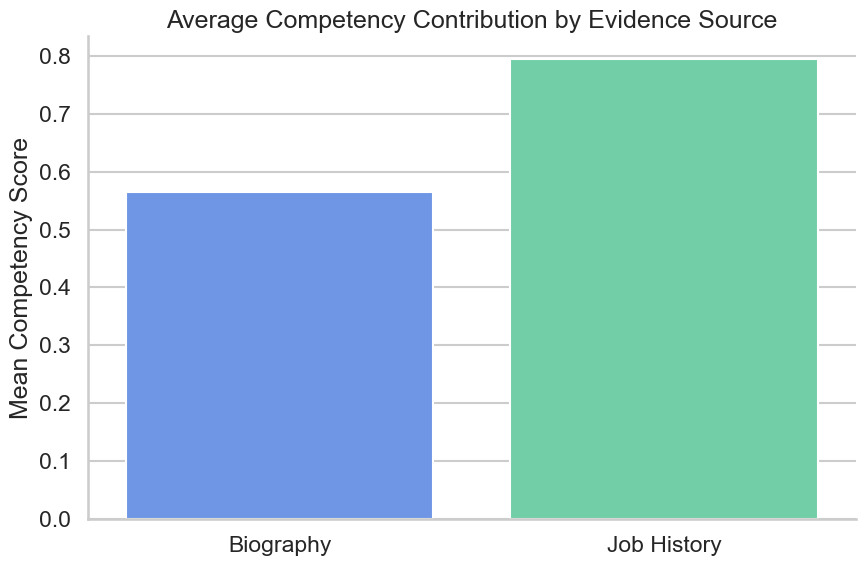

,Source,Mean Competency Score
0,Biography,0.565762
1,Job History,0.794552


In [7]:
source_means = pd.DataFrame(
    {
        "Source": ["Biography", "Job History"],
        "Mean Competency Score": [
            df["biography_competency_score"].mean(),
            df["job_description_competency_score"].mean(),
        ],
    }
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=source_means, x="Source", y="Mean Competency Score", palette=["#5B8FF9", "#61DDAA"], ax=ax)
ax.set_title("Average Competency Contribution by Evidence Source")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

source_means

/var/folders/8d/dffstnrn5js2s44pz0sfhd1w0000gn/T/ipykernel_11234/2910949063.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare_long, x="Source", y="Competency Score", palette=["#5B8FF9", "#61DDAA"], ax=ax)


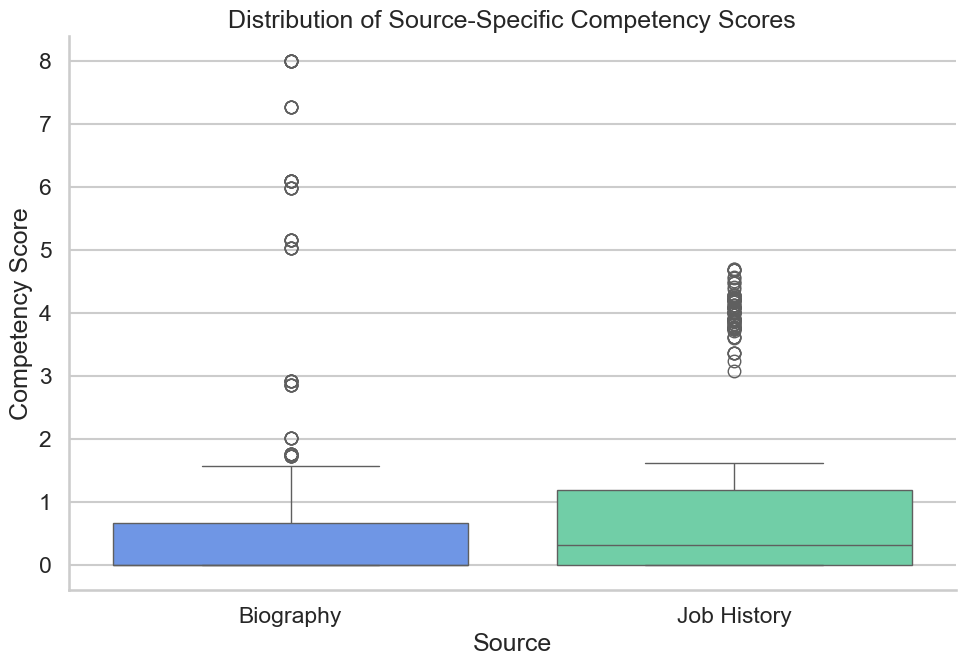

In [8]:
compare_df = df[["biography_competency_score", "job_description_competency_score"]].copy()
compare_df.columns = ["Biography", "Job History"]
compare_long = compare_df.melt(var_name="Source", value_name="Competency Score")

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(data=compare_long, x="Source", y="Competency Score", palette=["#5B8FF9", "#61DDAA"], ax=ax)
ax.set_title("Distribution of Source-Specific Competency Scores")
plt.tight_layout()
plt.show()

## 4. TF-IDF Comparison by Skill and Source

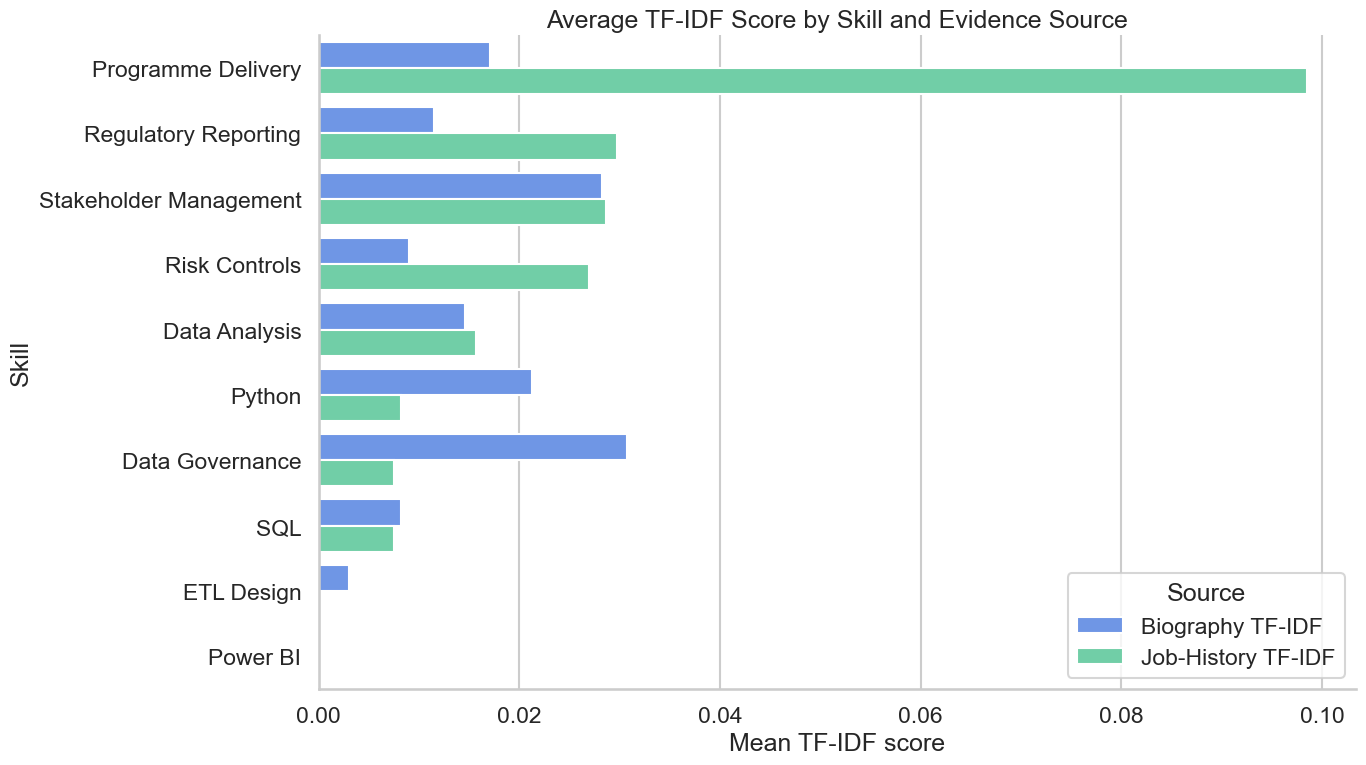

In [9]:
tfidf_skill = (
    df.groupby("skill", as_index=False)[["biography_tfidf_score", "job_description_tfidf_score"]]
    .mean()
    .sort_values("job_description_tfidf_score", ascending=False)
)
tfidf_long = tfidf_skill.melt(id_vars="skill", var_name="Source", value_name="Mean TF-IDF Score")
tfidf_long["Source"] = tfidf_long["Source"].map(
    {
        "biography_tfidf_score": "Biography TF-IDF",
        "job_description_tfidf_score": "Job-History TF-IDF",
    }
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=tfidf_long, y="skill", x="Mean TF-IDF Score", hue="Source", palette=["#5B8FF9", "#61DDAA"], ax=ax)
ax.set_title("Average TF-IDF Score by Skill and Evidence Source")
ax.set_xlabel("Mean TF-IDF score")
ax.set_ylabel("Skill")
plt.tight_layout()
plt.show()

## 5. Confidence Score Patterns

In [10]:
confidence_counts = pd.DataFrame(
    {
        "Biography": df["biography_confidence_score"].value_counts().sort_index(),
        "Job History": df["job_description_confidence_score"].value_counts().sort_index(),
    }
).fillna(0)
confidence_counts.index.name = "Confidence score"
confidence_counts

,Biography,Job History
Confidence score,,
0.0,463,436.0
0.4,541,614.0
0.7,46,0.0


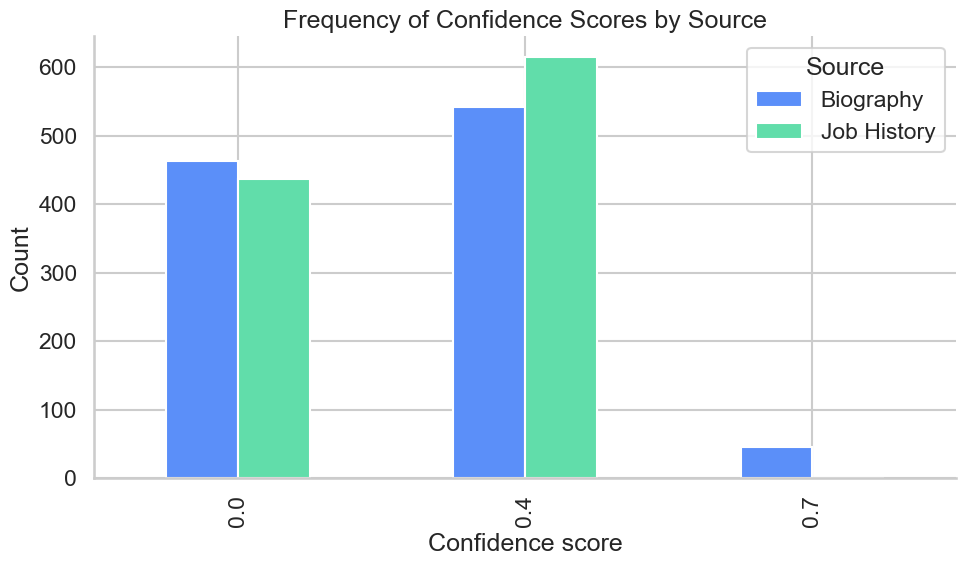

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
confidence_counts.plot(kind="bar", ax=ax, color=["#5B8FF9", "#61DDAA"])
ax.set_title("Frequency of Confidence Scores by Source")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.legend(title="Source")
plt.tight_layout()
plt.show()

## 6. Which Skills Rank First Most Often?

/var/folders/8d/dffstnrn5js2s44pz0sfhd1w0000gn/T/ipykernel_11234/2457399615.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank1, x="count", y="skill", palette="crest", ax=ax)


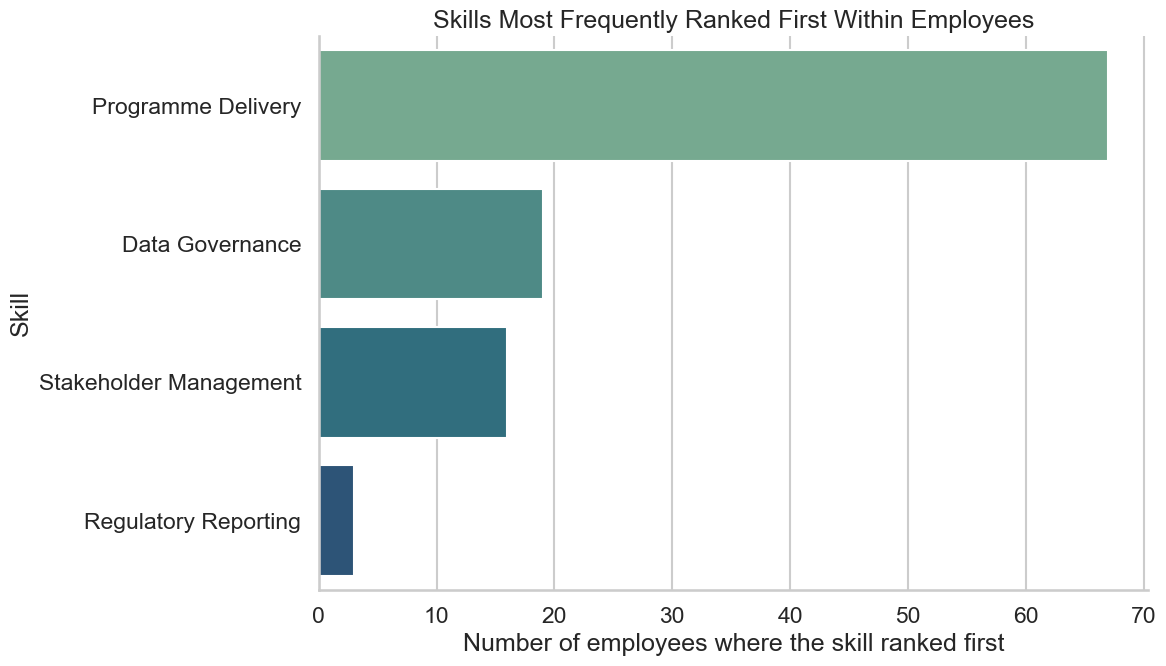

,skill,count
0,Programme Delivery,67
1,Data Governance,19
2,Stakeholder Management,16
3,Regulatory Reporting,3


In [12]:
rank1 = (
    df[df["competency_score_rank"] == 1]["skill"]
    .value_counts()
    .rename_axis("skill")
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=rank1, x="count", y="skill", palette="crest", ax=ax)
ax.set_title("Skills Most Frequently Ranked First Within Employees")
ax.set_xlabel("Number of employees where the skill ranked first")
ax.set_ylabel("Skill")
plt.tight_layout()
plt.show()

rank1

## 7. Employee-Level Summary View

In [13]:
employee_summary = (
    df.groupby("talentlinkId", as_index=False)
    .agg(
        mean_sum_competency=("sum_competency_score", "mean"),
        max_sum_competency=("sum_competency_score", "max"),
        mean_confidence=("confidence_score", "mean"),
    )
    .sort_values("max_sum_competency", ascending=False)
)

employee_summary.head(10)

,talentlinkId,mean_sum_competency,max_sum_competency,mean_confidence
40,853448,1.905,9.45,27.5
5,61645,1.909,9.38,27.5
100,90882505,1.930,9.21,27.5
28,473095,1.935,9.21,27.5
12,84177,1.925,9.20,27.5
34,626690,1.946,9.14,27.5
65,6943949,1.960,9.11,27.5
7,66881,1.947,9.09,27.5
35,662336,1.964,9.00,27.5
23,300845,1.964,7.62,31.5


## 8. Key Findings for the Report

- The final dataset contains one row per employee-skill pair.
- Competency scores are generally low to moderate, indicating sparse and uneven evidence across the dataset.
- Programme Delivery is the strongest skill on average and is most frequently ranked first.
- Biography and job history contribute differently, with job history driving some skills more strongly and biography contributing more to others such as Data Governance.
- Confidence scores are mostly low or zero, showing that the evidence is often weak even when TF-IDF overlap exists.
- The ranking column is useful for identifying the strongest evidenced skill per employee rather than interpreting every skill row in isolation.